<a href="https://colab.research.google.com/github/ss-sebastian/RSA-multilingual/blob/main/RSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path

BASE = Path("/content/RSA-multilingual/results/rsa_bert_sum/by_lang")  # 你这里必须是 /content 开头
first_lang = "en"

print("BASE exists:", BASE.exists(), BASE)
print("first_lang dir exists:", (BASE/first_lang).exists(), BASE/first_lang)

# 列出两层，看看有没有 rdm 相关文件夹/文件
p = BASE/first_lang
for x in sorted(p.glob("*")):
    print(x.name, "(dir)" if x.is_dir() else "")


BASE exists: True /content/RSA-multilingual/results/rsa_bert_sum/by_lang
first_lang dir exists: True /content/RSA-multilingual/results/rsa_bert_sum/by_lang/en
rdm_mats (dir)
rsa_result.json 


In [ ]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

SIM_DIR = Path("/content/RSA-multilingual/results/rsa_google_sum/rdm_similarity")

def parse_layer_from_name(name: str) -> int:
    # 支持: layer_-10 / layer-10 / layer -10 / layer--10
    m = re.search(r"layer[_\s-]*(-?\d+)", name)
    if not m:
        raise ValueError(f"Cannot parse layer from filename: {name}")
    return int(m.group(1))


def load_square_csv(p: Path) -> pd.DataFrame:
    # 你这里基本都是 DataFrame 存的矩阵：行列名都是语言
    df = pd.read_csv(p, index_col=0)
    # 防御：去掉可能的空列/空行
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    return df

# 1) 找到所有 layer 文件
files = sorted(SIM_DIR.glob("rdm_sim_*layer*.csv"))
if not files:
    raise FileNotFoundError(f"No rdm_sim_*layer*.csv under: {SIM_DIR}")

rows = []
for fp in files:
    L = parse_layer_from_name(fp.name)
    df = load_square_csv(fp)

    langs = list(df.index)
    mat = df.to_numpy(dtype=float)
    if mat.shape[0] != mat.shape[1]:
        raise ValueError(f"Not square: {fp} shape={mat.shape}")

    # 2) 取上三角 -> 语言对 rho
    for i in range(len(langs)):
        for j in range(i+1, len(langs)):
            rows.append({
                "layer": L,
                "lang_a": langs[i],
                "lang_b": langs[j],
                "rho": float(mat[i, j]),
                "file": fp.name
            })

df_pairs = pd.DataFrame(rows).sort_values(["layer","lang_a","lang_b"]).reset_index(drop=True)

# 3) layer-wise 平均（跨语言对）
df_layer = (df_pairs
            .groupby("layer")["rho"]
            .agg(mean="mean", n="count", sd="std")
            .reset_index()
            .sort_values("layer"))

display(df_pairs.head(10))
display(df_layer)


,layer,lang_a,lang_b,rho,file
0,1,en,de,0.242949,rdm_sim_layer_-1_spearman.csv
1,1,en,es,0.196191,rdm_sim_layer_-1_spearman.csv
2,1,en,it,0.171765,rdm_sim_layer_-1_spearman.csv
3,1,en,ru,-0.006472,rdm_sim_layer_-1_spearman.csv
4,1,en,zh,0.081667,rdm_sim_layer_-1_spearman.csv
5,1,es,de,0.127819,rdm_sim_layer_-1_spearman.csv
6,1,es,it,0.158822,rdm_sim_layer_-1_spearman.csv
7,1,es,ru,-0.000254,rdm_sim_layer_-1_spearman.csv
8,1,es,zh,0.031835,rdm_sim_layer_-1_spearman.csv
9,1,it,de,0.066500,rdm_sim_layer_-1_spearman.csv


,layer,mean,n,sd
0,1,0.089235,15,0.078392
1,2,0.110753,15,0.091263
2,3,0.100897,15,0.080777
3,4,0.098874,15,0.079362
4,5,0.103361,15,0.082622
5,6,0.112288,15,0.083178
6,7,0.104803,15,0.075164
7,8,0.114757,15,0.076078
8,9,0.138388,15,0.085093
9,10,0.140197,15,0.087477


Detected layers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] ... total 24
Detected language pairs: 15


,layer,mean_rho,ci_lo,ci_hi,n_pairs
0,1,0.089235,0.051787,0.129885,15
1,2,0.110753,0.067887,0.157288,15
2,3,0.100897,0.063647,0.141452,15
3,4,0.098874,0.061836,0.138890,15
4,5,0.103361,0.064245,0.145157,15


,pair,layer,mean_rho,ci_lo,ci_hi
0,de-en,1,0.242949,0.242949,0.242949
1,de-en,2,0.241815,0.241815,0.241815
2,de-en,3,0.216874,0.216874,0.216874
3,de-en,4,0.202229,0.202229,0.202229
4,de-en,5,0.211082,0.211082,0.211082


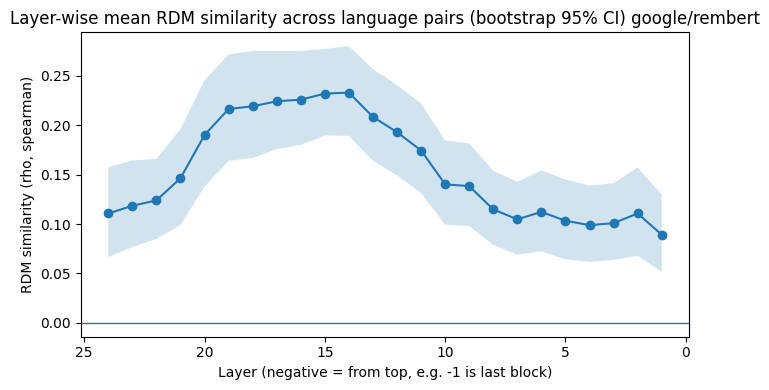

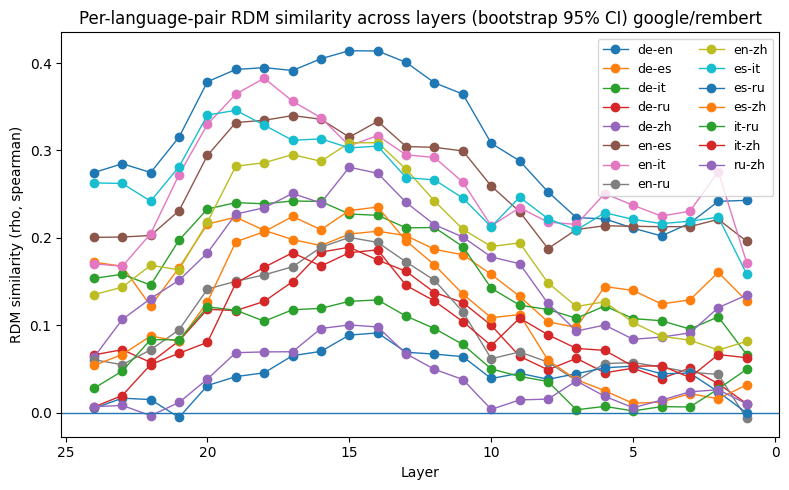

Saved:
- /content/RSA-multilingual/results/rsa_google_sum/rdm_pairwise_long_spearman.csv
- /content/RSA-multilingual/results/rsa_google_sum/rdm_layerwise_mean_ci_spearman.csv
- /content/RSA-multilingual/results/rsa_google_sum/rdm_pair_layerwise_mean_ci_spearman.csv


In [ ]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ========= 0) 路径：改这里 =========
RDM_SIM_DIR = Path("/content/RSA-multilingual/results/rsa_google_sum/rdm_similarity")  # 你的目录
METHOD = "spearman"  # 文件名里那个后缀

# ========= 1) 工具函数 =========
def parse_layer_from_name(name: str) -> int:
    # 支持 layer_-10 / layer-10 / layer -10
    m = re.search(r"layer[_\s-]*(-?\d+)", name)
    if not m:
        raise ValueError(f"Cannot parse layer from filename: {name}")
    return int(m.group(1))

def load_square_csv(p: Path) -> pd.DataFrame:
    """
    读一个 lang×lang 的相似度矩阵（csv），返回 DataFrame（index/columns=langs）
    """
    df = pd.read_csv(p, index_col=0)
    # 有时 index/col 会被读成数字字符串；统一成 str
    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)
    return df

def upper_tri_pairs(df: pd.DataFrame):
    """返回上三角(不含对角)的 (lang_i, lang_j, value) 列表"""
    langs = list(df.index)
    out = []
    for i in range(len(langs)):
        for j in range(i+1, len(langs)):
            out.append((langs[i], langs[j], float(df.iloc[i, j])))
    return out

def bootstrap_mean_ci(x, n_boot=5000, ci=95, seed=0):
    """
    对一维样本 x bootstrap 均值分布，返回 (mean, lo, hi, boot_means)
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan, np.array([])
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    boot = x[idx].mean(axis=1)
    lo = np.percentile(boot, (100-ci)/2)
    hi = np.percentile(boot, 100-(100-ci)/2)
    return float(x.mean()), float(lo), float(hi), boot

# ========= 2) 读入所有 layer 的矩阵，展开成 long-form =========
files = sorted(RDM_SIM_DIR.glob(f"rdm_sim_layer_*_{METHOD}.csv"))
if not files:
    raise FileNotFoundError(f"No files found in {RDM_SIM_DIR} matching rdm_sim_layer_*_{METHOD}.csv")

rows = []
for fp in files:
    L = parse_layer_from_name(fp.name)
    mat = load_square_csv(fp)
    for li, lj, v in upper_tri_pairs(mat):
        rows.append({"layer": L, "lang_i": li, "lang_j": lj, "rho": v, "file": fp.name})

df_pairs = pd.DataFrame(rows)
df_pairs["pair"] = df_pairs.apply(lambda r: "-".join(sorted([r["lang_i"], r["lang_j"]])), axis=1)

# 按 layer 排序（-12, -11, ..., -1）
layers = sorted(df_pairs["layer"].unique())
pairs = sorted(df_pairs["pair"].unique())

print("Detected layers:", layers[:10], "... total", len(layers))
print("Detected language pairs:", len(pairs))

# ========= 3) layer-wise mean rho + bootstrap CI =========
layer_stats = []
for L in layers:
    x = df_pairs.loc[df_pairs["layer"] == L, "rho"].to_numpy()
    mean, lo, hi, _ = bootstrap_mean_ci(x, n_boot=3000, ci=95, seed=42)
    layer_stats.append({"layer": L, "mean_rho": mean, "ci_lo": lo, "ci_hi": hi, "n_pairs": len(x)})

df_layer = pd.DataFrame(layer_stats).sort_values("layer")
display(df_layer.head())

# ========= 4) 每个语言对：每层 mean rho + bootstrap CI =========
pair_layer_stats = []
for pair in pairs:
    sub = df_pairs[df_pairs["pair"] == pair]
    for L in layers:
        x = sub.loc[sub["layer"] == L, "rho"].to_numpy()
        mean, lo, hi, _ = bootstrap_mean_ci(x, n_boot=3000, ci=95, seed=123)
        pair_layer_stats.append({"pair": pair, "layer": L, "mean_rho": mean, "ci_lo": lo, "ci_hi": hi})

df_pair_layer = pd.DataFrame(pair_layer_stats).sort_values(["pair", "layer"])
display(df_pair_layer.head())

# ========= 5) 图A：layer-wise mean ± CI =========
plt.figure(figsize=(7,4))
x = df_layer["layer"].to_numpy()
y = df_layer["mean_rho"].to_numpy()
ylo = df_layer["ci_lo"].to_numpy()
yhi = df_layer["ci_hi"].to_numpy()

plt.plot(x, y, marker="o")
plt.fill_between(x, ylo, yhi, alpha=0.2)
plt.axhline(0, linewidth=1)

plt.xlabel("Layer (negative = from top, e.g. -1 is last block)")
plt.ylabel(f"RDM similarity (rho, {METHOD})")
plt.title("Layer-wise mean RDM similarity across language pairs (bootstrap 95% CI) google/rembert")
plt.gca().invert_xaxis()  # 让 -1 在右边（更“深层”在右），不喜欢就删掉
plt.tight_layout()
plt.show()

# ========= 6) 图B：每个语言对的曲线 =========
# 如果语言很多(比如6种=15对)会很挤；你可以只选最关心的6对
SELECT_PAIRS = None  # 例如: ["en-es","en-zh","es-zh","en-de","en-ru","en-it"]

plot_df = df_pair_layer.copy()
if SELECT_PAIRS is not None:
    plot_df = plot_df[plot_df["pair"].isin(SELECT_PAIRS)]

plt.figure(figsize=(8,5))
for pair, g in plot_df.groupby("pair"):
    g = g.sort_values("layer")
    plt.plot(g["layer"], g["mean_rho"], marker="o", linewidth=1, label=pair)
    plt.fill_between(g["layer"], g["ci_lo"], g["ci_hi"], alpha=0.15)

plt.axhline(0, linewidth=1)
plt.xlabel("Layer")
plt.ylabel(f"RDM similarity (rho, {METHOD})")
plt.title("Per-language-pair RDM similarity across layers (bootstrap 95% CI) google/rembert")
plt.gca().invert_xaxis()
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# ========= 7) 保存统计表 =========
out_dir = RDM_SIM_DIR.parent  # results/rsa_bert_sum
df_pairs.to_csv(out_dir / f"rdm_pairwise_long_{METHOD}.csv", index=False)
df_layer.to_csv(out_dir / f"rdm_layerwise_mean_ci_{METHOD}.csv", index=False)
df_pair_layer.to_csv(out_dir / f"rdm_pair_layerwise_mean_ci_{METHOD}.csv", index=False)

print("Saved:",
      out_dir / f"rdm_pairwise_long_{METHOD}.csv",
      out_dir / f"rdm_layerwise_mean_ci_{METHOD}.csv",
      out_dir / f"rdm_pair_layerwise_mean_ci_{METHOD}.csv",
      sep="\n- ")


[info] detected n_blocks = 11


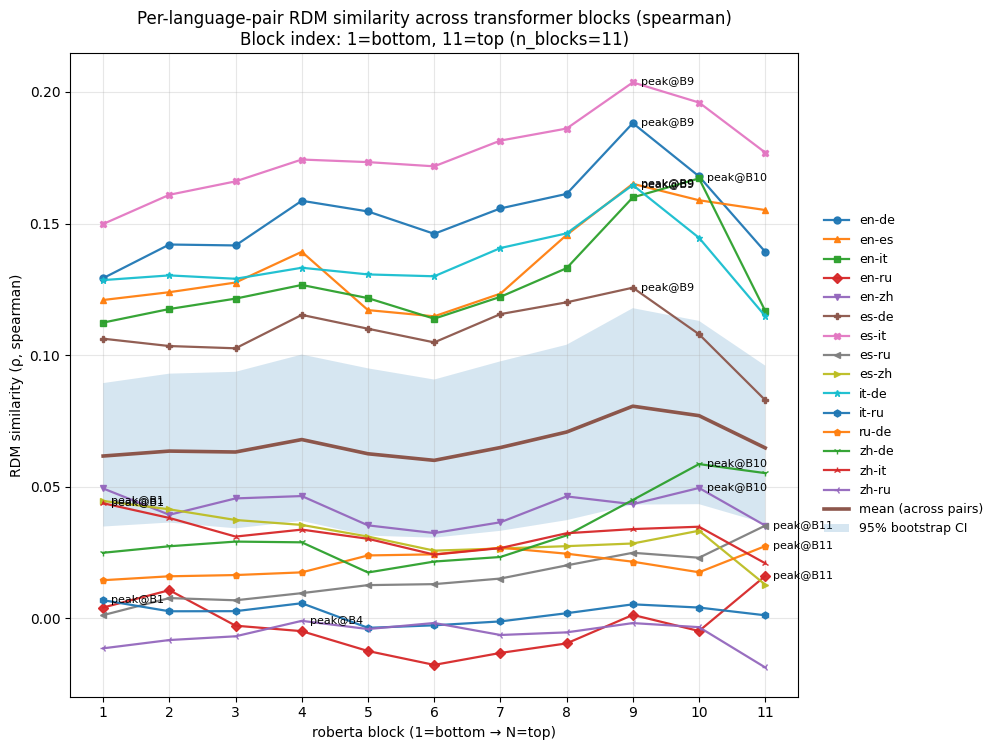

Saved:
 - /content/RSA-multilingual/results/rsa_roberta_sum/rdm_similarity/blockwise_pair_long_spearman.csv
 - /content/RSA-multilingual/results/rsa_roberta_sum/rdm_similarity/pairwise_peaks_spearman.csv (this is your 'pair -> peak' table)
 - /content/RSA-multilingual/results/rsa_roberta_sum/rdm_similarity/blockwise_mean_ci_spearman.csv


In [36]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= 1) 改这里：你的 rdm_similarity 文件夹 =========
RDM_SIM_DIR = Path("/content/RSA-multilingual/results/rsa_roberta_sum/rdm_similarity")
METHOD = "spearman"   # 或 "pearson"

# ========= helpers =========
def parse_layer_neg(fname: str) -> int:
    """
    Parse negative layer index from filename.
    Accepts variants like:
      rdm_sim_layer_-10_spearman.csv
      rdm_sim_layer-10_spearman.csv
      rdm_sim_rdm_layer-10_spearman.csv
    """
    m = re.search(r"(?:layer[_-])(-?\d+)", fname)
    if not m:
        raise ValueError(f"Cannot parse layer from filename: {fname}")
    return int(m.group(1))

def infer_n_blocks_from_files(files) -> int:
    negs = [parse_layer_neg(fp.name) for fp in files]
    max_abs = max(abs(x) for x in negs)

    # If embeddings are included, you often see both -(N+1) and -N
    has_minus_max = (-max_abs in negs)
    has_minus_max_minus1 = (-(max_abs - 1) in negs) if max_abs > 1 else False
    if has_minus_max and has_minus_max_minus1:
        return max_abs - 1
    return max_abs

def neg_to_block_index(layer_neg: int, n_blocks: int) -> int:
    """
    -1 -> n_blocks (top)
    -n_blocks -> 1 (bottom)
    -(n_blocks+1) -> 0 (embeddings) if present
    """
    return (n_blocks + 1) + layer_neg

def load_square_df(p: Path) -> pd.DataFrame:
    df = pd.read_csv(p, index_col=0)
    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)
    # numeric coercion
    df = df.apply(pd.to_numeric, errors="coerce")
    return df

def bootstrap_ci(vals, n_boot=4000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan, np.nan
    means = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        samp = rng.choice(vals, size=len(vals), replace=True)
        means[b] = np.mean(samp)
    lo = np.percentile(means, (100 - ci) / 2)
    hi = np.percentile(means, 100 - (100 - ci) / 2)
    return float(np.mean(vals)), float(lo), float(hi)

# ========= 2) 读入所有 layer 的语言×语言相似度矩阵，转成长表 =========
files = sorted(RDM_SIM_DIR.glob(f"rdm_sim*layer*_{METHOD}.csv"))
if not files:
    raise FileNotFoundError(f"No rdm_sim*layer*_{METHOD}.csv found in {RDM_SIM_DIR}")

N_BLOCKS = infer_n_blocks_from_files(files)
print(f"[info] detected n_blocks = {N_BLOCKS}")

rows = []
for fp in files:
    Lneg = parse_layer_neg(fp.name)
    block = int(neg_to_block_index(Lneg, n_blocks=N_BLOCKS))  # 1..N, embedding would be 0
    df = load_square_df(fp)

    langs = list(df.index)
    for i in range(len(langs)):
        for j in range(i + 1, len(langs)):
            li, lj = langs[i], langs[j]
            val = df.loc[li, lj]
            rows.append({
                "layer_neg": int(Lneg),
                "block": int(block),
                "pair": f"{li}-{lj}",
                "lang_i": li,
                "lang_j": lj,
                "rho": float(val) if pd.notna(val) else np.nan,
            })

long = pd.DataFrame(rows).sort_values(["block", "pair"]).reset_index(drop=True)

# 如果你不想把 embedding 当成一层，就丢掉 block==0
long = long[long["block"] != 0].copy()

# ========= 3) 生成 “pair -> peak block, peak rho” 表格（保存成 CSV） =========
peak_tbl = (
    long.loc[long.groupby("pair")["rho"].idxmax(), ["pair", "lang_i", "lang_j", "block", "rho"]]
    .rename(columns={"block": "peak_block", "rho": "peak_rho"})
    .sort_values("peak_rho", ascending=False)
    .reset_index(drop=True)
)

# 额外加一列：你原来的负索引峰值（方便对照）
# peak_block -> layer_neg 的一一映射并不总是唯一（如果有缺层文件），这里用 block->median layer_neg 近似
block2neg = (
    long.groupby("block")["layer_neg"]
    .median()
    .round()
    .astype(int)
    .to_dict()
)
peak_tbl["peak_layer_neg_approx"] = peak_tbl["peak_block"].map(block2neg)

# ========= 4) block-wise mean + bootstrap CI（跨所有 pair） =========
summary = []
for b in sorted(long["block"].unique()):
    vals = long.loc[long["block"] == b, "rho"].values
    m, lo, hi = bootstrap_ci(vals, n_boot=4000, ci=95, seed=123 + int(b))
    summary.append({"block": int(b), "mean_rho": m, "ci_lo": lo, "ci_hi": hi})
summary = pd.DataFrame(summary).sort_values("block").reset_index(drop=True)

# ========= 5) 作图：不在图里显示右下角 Peaks 文本，改为只保存 peak_tbl =========
plt.figure(figsize=(13.0, 7.6))

markers = ["o", "^", "s", "D", "v", "P", "X", "<", ">", "*", "h", "p", "1", "2", "3", "4", "+", "x"]
linestyles = ["-", "--", "-.", ":"]
pairs_sorted = sorted(long["pair"].unique())

unique_blocks = sorted(long["block"].unique())
mark_every = max(1, len(unique_blocks) // 6)

for k, pair in enumerate(pairs_sorted):
    dfp = long[long["pair"] == pair].sort_values("block")
    mk = markers[k % len(markers)]
    ls = linestyles[(k // len(markers)) % len(linestyles)]
    plt.plot(
        dfp["block"],
        dfp["rho"],
        linewidth=1.6,
        linestyle=ls,
        marker=mk,
        markersize=5,
        markevery=mark_every,
        label=pair,
        alpha=0.95,
    )

# mean + CI
plt.plot(summary["block"], summary["mean_rho"], linewidth=2.6, label="mean (across pairs)")
plt.fill_between(summary["block"], summary["ci_lo"], summary["ci_hi"], alpha=0.18, label="95% bootstrap CI")

# 标注每条曲线的 peak（仅写 peak@Bx，不放大段文本）
# 用 peak_tbl 来驱动
for _, r in peak_tbl.iterrows():
    pair = r["pair"]
    bpk = int(r["peak_block"])
    sel = long[(long["pair"] == pair) & (long["block"] == bpk)]["rho"]
    if len(sel) == 0:
        continue
    ypk = float(sel.iloc[0])
    plt.text(bpk + 0.12, ypk, f"peak@B{bpk}", fontsize=8, va="center")

plt.title(
    f"Per-language-pair RDM similarity across transformer blocks ({METHOD})\n"
    f"Block index: 1=bottom, {max(unique_blocks)}=top (n_blocks={N_BLOCKS})"
)
plt.xlabel("roberta block (1=bottom → N=top)")
plt.ylabel(f"RDM similarity (ρ, {METHOD})")
plt.xticks(unique_blocks)
plt.grid(True, alpha=0.3)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=False,
    ncol=1,
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

# ========= 6) 保存（图外：保存成表格） =========
out_long = RDM_SIM_DIR / f"blockwise_pair_long_{METHOD}.csv"
out_peak = RDM_SIM_DIR / f"pairwise_peaks_{METHOD}.csv"
out_sum  = RDM_SIM_DIR / f"blockwise_mean_ci_{METHOD}.csv"

long.to_csv(out_long, index=False)
peak_tbl.to_csv(out_peak, index=False)
summary.to_csv(out_sum, index=False)

print("Saved:")
print(" -", out_long)
print(" -", out_peak, "(this is your 'pair -> peak' table)")
print(" -", out_sum)


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import itertools
import matplotlib.pyplot as plt

# ==========
# 0) 配置路径
# ==========
ROOT = Path("content/RSA-multilingual")   # 如果你不是在 colab 这个路径，改这里
BASE = ROOT / "results" / "rsa_bert_sum" / "by_lang"  # 按你截图
LANGS = ["en","es","zh","de","it","ru"]  # 你实际跑了哪些就写哪些

# ==========
# 1) 读取每个语言的 rdm_layer*.csv 路径
# ==========
def collect_layer_files(lang_dir: Path):
    files = sorted(lang_dir.glob("**/rdm_layer*.csv"))
    if not files:
        raise FileNotFoundError(f"No rdm_layer*.csv under {lang_dir}")
    # layer id 从文件名里抓：rdm_layer-3.csv -> -3
    layer2path = {}
    for p in files:
        stem = p.stem  # rdm_layer-3
        layer_str = stem.replace("rdm_layer", "")  # "-3" or "_-3" depending
        layer_str = layer_str.replace("_","")
        layer = int(layer_str)
        layer2path[layer] = p
    return layer2path

# 你前面定义过 load_rdm_csv / upper_tri，就直接用
# (这里假设你已经运行了那段 robust loader)

lang2layer2path = {}
for lg in LANGS:
    lang_dir = BASE / lg
    lang2layer2path[lg] = collect_layer_files(lang_dir)

# 统一所有语言都共有的 layers（避免某个语言缺层）
common_layers = sorted(set.intersection(*(set(d.keys()) for d in lang2layer2path.values())))
print("Common layers:", common_layers[:5], "... total", len(common_layers))

# ==========
# 2) 读入并向量化 upper-tri (language × layer -> vector)
# ==========
vecs = {lg: {} for lg in LANGS}
for lg in LANGS:
    for L in common_layers:
        mat = load_rdm_csv(lang2layer2path[lg][L])
        vecs[lg][L] = upper_tri(mat)

print("Example vector length:", len(vecs[LANGS[0]][common_layers[0]]))

# ==========
# 3) Spearman 相关（不用 scipy：rank->pearson）
# ==========
def spearman_corr(a, b):
    a = pd.Series(a).rank(method="average").to_numpy()
    b = pd.Series(b).rank(method="average").to_numpy()
    a = a - a.mean()
    b = b - b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a,b) / denom) if denom != 0 else float("nan")

pairs = list(itertools.combinations(LANGS, 2))  # 6 languages -> 15 pairs
print("Num pairs:", len(pairs))

# layer-wise: 每层每个 pair 一个 rho
rows = []
for L in common_layers:
    for (a,b) in pairs:
        rho = spearman_corr(vecs[a][L], vecs[b][L])
        rows.append({"layer": L, "lang_a": a, "lang_b": b, "rho": rho})
df_pair = pd.DataFrame(rows)
df_pair.head()


FileNotFoundError: No rdm_layer*.csv under content/RSA-multilingual/results/rsa_bert_sum/by_lang/en